# Подготовка тестовых данных

Ноутбук выполняет предобработку тестовой выборки по аналогии с тренировочным пайплайном (`01a`-`01c`).

Источники тестовых данных:
1. **test_clear.json** — чистые сообщения из открытых Telegram чатов различных ВУЗов (ham, label=0)
2. **parsed_lols_2023.txt** — спам-сообщения с lols.bot, 2023 год (spam, label=1)

Этапы обработки:
1. Загрузка и объединение тестовых данных
2. Очистка (пустые, короткие, дедупликация)
3. Препроцессинг и извлечение 20 числовых признаков
4. Анализ тестового датасета
5. Сохранение в `data/processed/test_preprocessed.csv`

Результат используется в `05_additional_evaluation.ipynb` для оценки моделей на внешних данных.

## Импорт необходимых библиотек

Используются `pandas`, `numpy` и модули проекта:
- `src.data.loaders` — загрузка TXT файлов
- `src.data.preprocessing` — предобработка текста
- `src.features.extractors` — извлечение числовых признаков
- `src.config` — пути к директориям данных

In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.data.loaders import load_txt_lines
from src.data.preprocessing import preprocess_text, normalize_unicode, strip_html
from src.features.extractors import (
    count_emojis,
    count_newlines,
    count_whitespaces,
    count_links,
    count_tags,
    capital_ratio,
    count_punctuation,
    count_digits,
    avg_word_length,
    word_count,
    unique_word_ratio,
    repeat_char_ratio,
    count_phone_numbers,
    has_crypto_mention,
    count_exclamation,
    url_ratio,
    count_html_tags,
    has_markdown_formatting,
    emoji_diversity,
)
from src.config import RAW_DIR, EXTERNAL_DIR, PROCESSED_DIR

from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка тестовых данных

Тестовые данные загружаются из двух независимых источников,
не пересекающихся с обучающей выборкой (пересечения удалены в `01b_data_cleaning.ipynb`).

### Данные с чистыми сообщениями

`data/raw/test_clear.json` — сообщения из открытых Telegram чатов различных ВУЗов.
Все сообщения имеют метку 0 (ham).

In [2]:
df_clear = pd.read_json(RAW_DIR / 'test_clear.json')
print(f'Загружено из test_clear.json: {len(df_clear)} строк')
df_clear.head()

Загружено из test_clear.json: 25274 строк


,text,label
0,"Здравствуйте, подскажите, пожалуйста, программ...",0
1,"Получается, все тоже самое, но теперь диплом т...",0
2,"Извините, а где можно узнать Актуальные маг пр...",0
3,"Добрый вечер, подскажите пожалуйста, есть ли з...",0
4,Здравствуйте! Только очная форма обучения,0


In [3]:
df_clear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25274 entries, 0 to 25273
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25274 non-null  object
 1   label   25274 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 395.0+ KB


### Данные со спам-сообщениями

`data/external/parsed_lols_2023.txt` — спам-сообщения с lols.bot (2023 год).
Все сообщения имеют метку 1 (spam).
При загрузке первый `<br/>` удаляется, остальные заменяются на перенос строки.

In [4]:
_lines_2023 = load_txt_lines(EXTERNAL_DIR / 'parsed_lols_2023.txt')
_spam_texts = [l.replace('<br/>', '', 1).strip().replace('<br/>', '\n') for l in _lines_2023 if l.strip()]
df_spam = pd.DataFrame({'text': _spam_texts, 'label': [1] * len(_spam_texts)})
print(f'Загружено из parsed_lols_2023.txt: {len(df_spam)} строк')
df_spam.head()

Загружено из parsed_lols_2023.txt: 32437 строк


,text,label
0,🤝ƃАЗA ЧAT𝖮B ᎩCЛᎩГ🤝 + Б𝖮Т AВTОРАСCЫЛKИ🚀<br>\n❗️...,1
1,دانیالللل,1
2,🤙🏻🤘🏻Caмo𝚎 cлoжное нa сеpoм рынке — это найти н...,1
3,𝙇 𝘼 𝙈 𝙄 𝘼,1
4,🔲DROP SERVICE🔲<br><br>☕️ 𝔸ℝ𝔸𝔹𝕀ℂ𝔸×ℝ𝕆𝔹𝕌𝕊𝕋𝔸 ☕️ \n...,1


### Объединение данных

Чистые и спам-сообщения объединяются в один тестовый датафрейм.

In [5]:
df_test = pd.concat([df_clear, df_spam], ignore_index=True)
print(f'Всего тестовых строк: {len(df_test)}')
print(f"  Ham (0): {len(df_test[df_test['label'] == 0])}")
print(f"  Spam (1): {len(df_test[df_test['label'] == 1])}")
df_test.head()

Всего тестовых строк: 57711
  Ham (0): 25274
  Spam (1): 32437


,text,label
0,"Здравствуйте, подскажите, пожалуйста, программ...",0
1,"Получается, все тоже самое, но теперь диплом т...",0
2,"Извините, а где можно узнать Актуальные маг пр...",0
3,"Добрый вечер, подскажите пожалуйста, есть ли з...",0
4,Здравствуйте! Только очная форма обучения,0


## Очистка тестовых данных

#### Точная дедупликация

Удаляются полные дубликаты по полю `text` (оставляется первое вхождение).

In [6]:
df_1 = df_test[df_test['text'].notna()]
_before_dedup = len(df_1)
df_2 = df_1.drop_duplicates(subset='text', keep='first').copy()
print(f'Удалено дубликатов: {_before_dedup - len(df_2)}')
print(f'После дедупликации: {len(df_2)} строк')

Удалено дубликатов: 16152
После дедупликации: 41559 строк


## Препроцессинг и извлечение признаков

Создаются три версии текста:
- `text_raw` — исходный текст без изменений
- `text_normalized` — NFKC + удаление HTML (для BERT)
- `text_preprocessed` — полная предобработка (для TF-IDF и классических моделей)

Дополнительно извлекаются 20 числовых признаков из исходного текста.
Полностью повторяет логику `01c_preprocessing.ipynb`.

### Извлечение числовых признаков

Из исходного текста извлекаются числовые признаки, идентичные тренировочному датасету.

In [7]:
df_prep = deepcopy(df_2)
df_prep['emojis'] = df_2['text'].apply(count_emojis)
df_prep['newlines'] = df_2['text'].apply(count_newlines)
df_prep['whitespaces'] = df_2['text'].apply(count_whitespaces)
df_prep['links'] = df_2['text'].apply(count_links)
df_prep['tags'] = df_2['text'].apply(count_tags)
df_prep['length'] = df_2['text'].str.len()
df_prep['capital_ratio'] = df_2['text'].apply(capital_ratio)
df_prep['punctuation_count'] = df_2['text'].apply(count_punctuation)
df_prep['digit_count'] = df_2['text'].apply(count_digits)
df_prep['avg_word_length'] = df_2['text'].apply(avg_word_length)
df_prep['word_count'] = df_2['text'].apply(word_count)
df_prep['unique_word_ratio'] = df_2['text'].apply(unique_word_ratio)
df_prep['repeat_char_ratio'] = df_2['text'].apply(repeat_char_ratio)
df_prep['phone_count'] = df_2['text'].apply(count_phone_numbers)
df_prep['has_crypto'] = df_2['text'].apply(has_crypto_mention)
df_prep['exclamation_count'] = df_2['text'].apply(count_exclamation)
df_prep['url_ratio'] = df_2['text'].apply(url_ratio)
df_prep['html_tag_count'] = df_2['text'].apply(count_html_tags)
df_prep['has_markdown'] = df_2['text'].apply(has_markdown_formatting)
df_prep['emoji_diversity'] = df_2['text'].apply(emoji_diversity)
print(f'Признаков извлечено: {df_prep.shape[1] - 3} числовых колонок')
print(f'Всего колонок: {df_prep.shape[1]}')

Признаков извлечено: 19 числовых колонок
Всего колонок: 22


### Создание трёх версий текста

- `text_raw` — исходный текст (без изменений)
- `text_normalized` — NFKC + удаление HTML и невидимых символов (для BERT)
- `text_preprocessed` — полная предобработка (для классических моделей + TF-IDF)

In [8]:
df_prep['text_raw'] = df_2['text'].values
df_prep['text_normalized'] = df_2['text'].apply(lambda t: normalize_unicode(strip_html(str(t))))
texts = df_2['text'].apply(lambda t: preprocess_text(str(t)))
texts = texts.replace('', np.nan)
df_prep['text_preprocessed'] = texts.values
df_prep.head()

,text,label,emojis,newlines,whitespaces,links,tags,length,capital_ratio,punctuation_count,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
0,"Здравствуйте, подскажите, пожалуйста, программ...",0,0,3,2,1,0,225,0.016304,20,...,0,0,0,0.537778,0,0,0,"Здравствуйте, подскажите, пожалуйста, программ...","Здравствуйте, подскажите, пожалуйста, программ...",здравствуйте подскажите пожалуйста программу м...
1,"Получается, все тоже самое, но теперь диплом т...",0,0,0,0,0,0,63,0.019231,3,...,0,0,0,0.000000,0,0,0,"Получается, все тоже самое, но теперь диплом т...","Получается, все тоже самое, но теперь диплом т...",получается все тоже самое но теперь диплом тол...
2,"Извините, а где можно узнать Актуальные маг пр...",0,0,0,0,0,0,81,0.029412,3,...,0,0,0,0.000000,0,0,0,"Извините, а где можно узнать Актуальные маг пр...","Извините, а где можно узнать Актуальные маг пр...",извините а где можно узнать актуальные маг про...
3,"Добрый вечер, подскажите пожалуйста, есть ли з...",0,0,0,0,0,0,110,0.021053,3,...,0,0,0,0.000000,0,0,0,"Добрый вечер, подскажите пожалуйста, есть ли з...","Добрый вечер, подскажите пожалуйста, есть ли з...",добрый вечер подскажите пожалуйста есть ли зао...
4,Здравствуйте! Только очная форма обучения,0,0,0,0,0,0,41,0.055556,1,...,0,0,1,0.000000,0,0,0,Здравствуйте! Только очная форма обучения,Здравствуйте! Только очная форма обучения,здравствуйте только очная форма обучения


### Удаление строк с пустым `text_preprocessed`

Удаляются строки, где `text_preprocessed` оказался пустым после предобработки.

In [9]:
print(f'Пустых text_preprocessed: {df_prep["text_preprocessed"].isna().sum()}')
df_prep.dropna(subset=['text_preprocessed'], inplace=True)
df_prep.reset_index(drop=True, inplace=True)
df_prep.info()

Пустых text_preprocessed: 190
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41369 entries, 0 to 41368
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               41369 non-null  object 
 1   label              41369 non-null  int64  
 2   emojis             41369 non-null  int64  
 3   newlines           41369 non-null  int64  
 4   whitespaces        41369 non-null  int64  
 5   links              41369 non-null  int64  
 6   tags               41369 non-null  int64  
 7   length             41369 non-null  int64  
 8   capital_ratio      41369 non-null  float64
 9   punctuation_count  41369 non-null  int64  
 10  digit_count        41369 non-null  int64  
 11  avg_word_length    41369 non-null  float64
 12  word_count         41369 non-null  int64  
 13  unique_word_ratio  41369 non-null  float64
 14  repeat_char_ratio  41369 non-null  float64
 15  phone_count        41369 non-null  int64

## Анализ тестового датасета

Визуализация распределения классов, корреляция признаков с целевой переменной
и примеры препроцессинга.

### Распределение классов

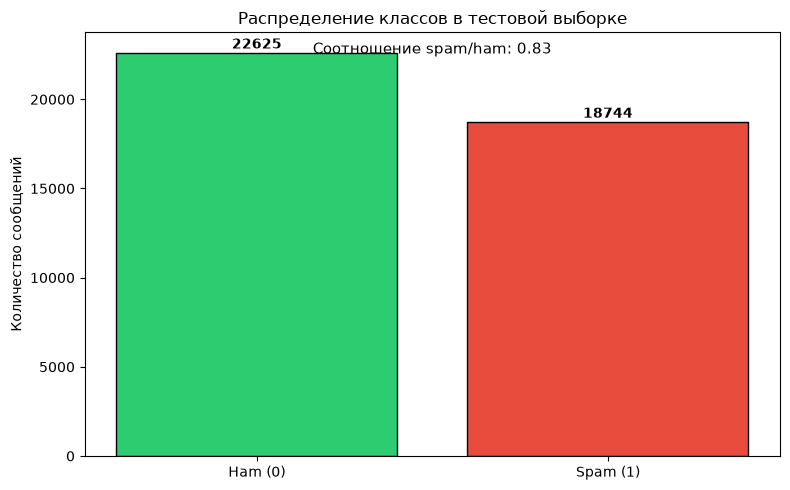


Итого: 41369 строк
  Ham (0): 22625
  Spam (1): 18744
  Соотношение: 0.83


In [10]:
_fig, _ax = plt.subplots(figsize=(8, 5))
_class_counts = df_prep['label'].value_counts().sort_index()
_ax.bar(['Ham (0)', 'Spam (1)'], _class_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for _i, _v in enumerate(_class_counts.values):
    _ax.text(_i, _v + max(_class_counts.values) * 0.01, str(_v), ha='center', fontweight='bold')
_ax.set_title('Распределение классов в тестовой выборке')
_ax.set_ylabel('Количество сообщений')
_ratio = _class_counts.get(1, 0) / max(_class_counts.get(0, 1), 1)
_ax.text(0.5, 0.95, f'Соотношение spam/ham: {_ratio:.2f}', transform=_ax.transAxes, ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nИтого: {len(df_prep)} строк')
print(f"  Ham (0): {len(df_prep[df_prep['label'] == 0])}")
print(f"  Spam (1): {len(df_prep[df_prep['label'] == 1])}")
print(f"  Соотношение: {_ratio:.2f}")

### Корреляция числовых признаков с целевой переменной

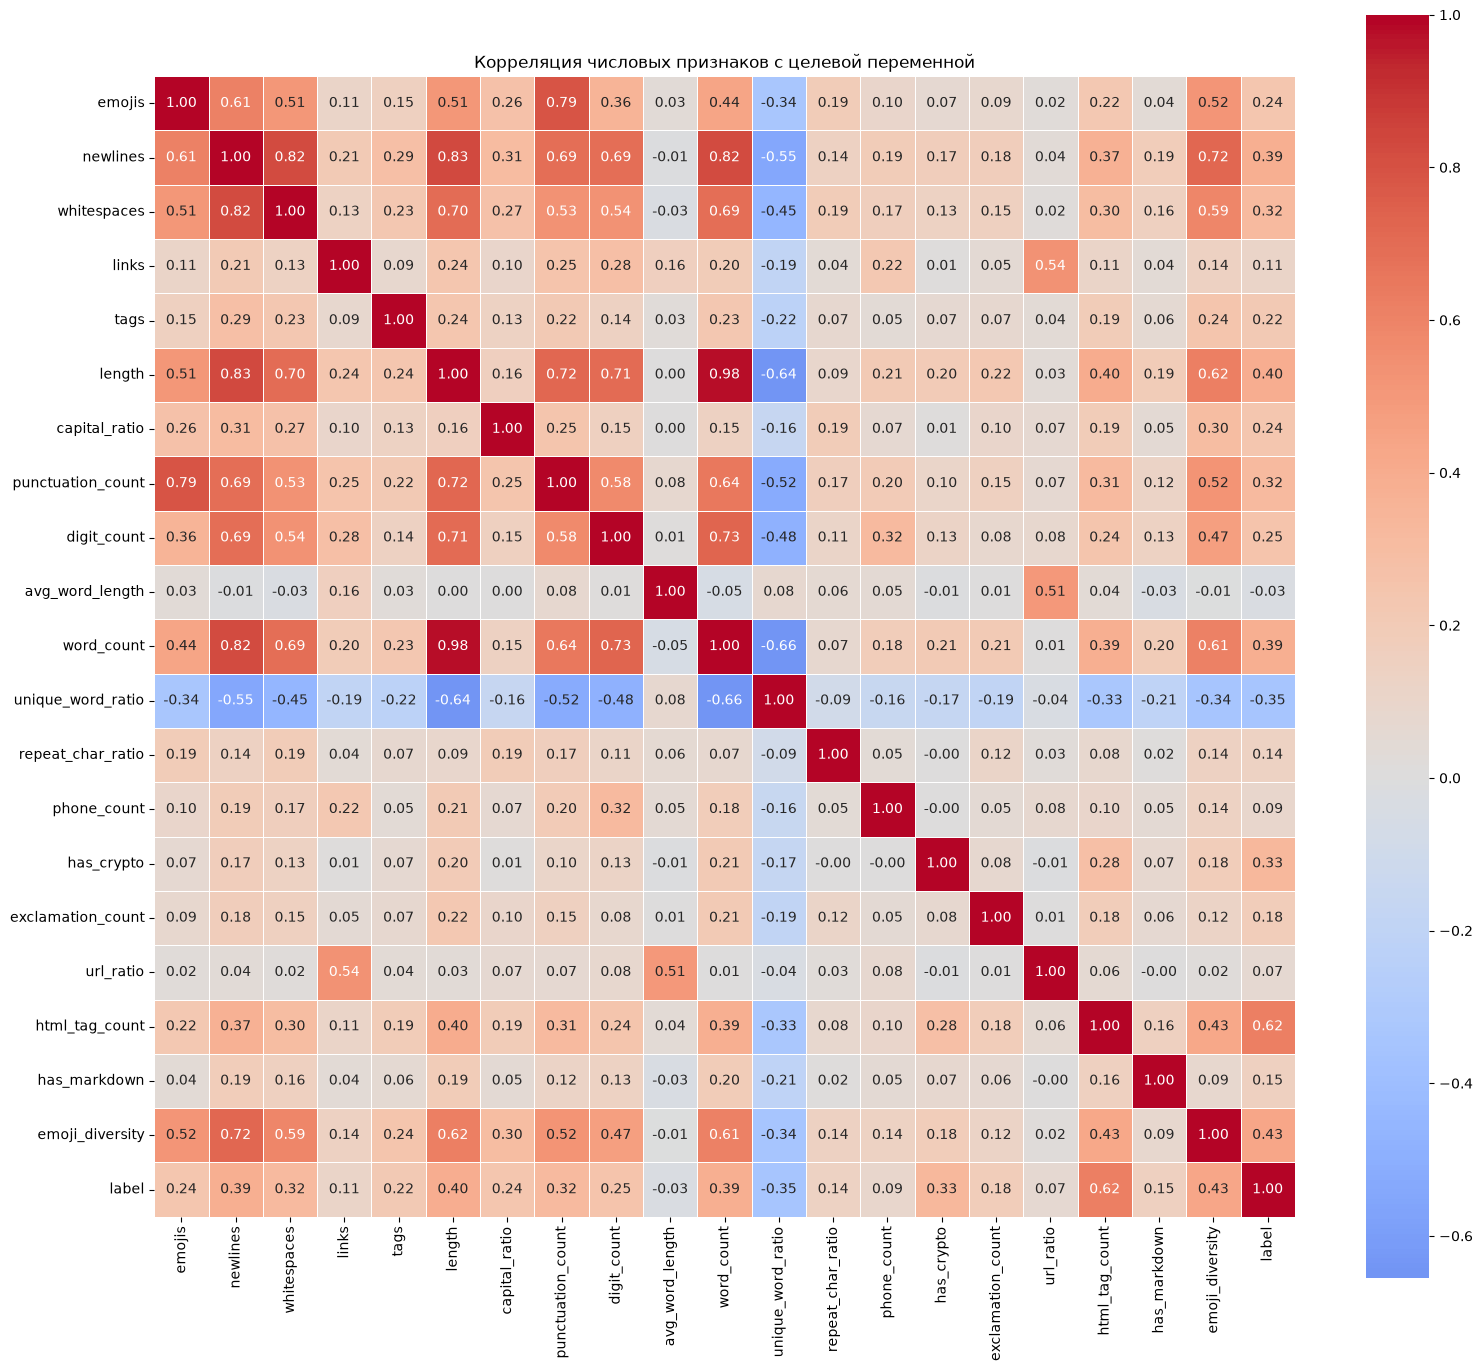

In [11]:
_numeric_cols = [
    'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'length',
    'capital_ratio', 'punctuation_count', 'digit_count', 'avg_word_length',
    'word_count', 'unique_word_ratio', 'repeat_char_ratio', 'phone_count',
    'has_crypto', 'exclamation_count', 'url_ratio', 'html_tag_count',
    'has_markdown', 'emoji_diversity', 'label',
]
_corr = df_prep[_numeric_cols].corr()
_fig, _ax = plt.subplots(figsize=(16, 14))
sns.heatmap(_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=_ax, square=True, linewidths=0.5)
_ax.set_title('Корреляция числовых признаков с целевой переменной')
plt.tight_layout()
plt.show()

### Примеры препроцессинга (до/после)

Примеры исходного, нормализованного и полностью предобработанного текста
для каждого класса.

In [12]:
for _label, _label_name in [(0, 'Ham'), (1, 'Spam')]:
    _subset = df_prep[df_prep['label'] == _label].head(5)
    print(f'\n--- {_label_name} (label={_label}) ---')
    for _idx, _row in _subset.iterrows():
        _raw = str(_row['text_raw'])[:100]
        _norm = str(_row['text_normalized'])[:100]
        _prep = str(_row['text_preprocessed'])[:100]
        print(f'\n  text_raw:        {_raw}')
        print(f'  text_normalized: {_norm}')
        print(f'  text_preprocessed: {_prep}')


--- Ham (label=0) ---

  text_raw:        Здравствуйте, подскажите, пожалуйста, программу магистерскую с университетом Туши не убрали? 
Вот эт
  text_normalized: Здравствуйте, подскажите, пожалуйста, программу магистерскую с университетом Туши не убрали? 
Вот эт
  text_preprocessed: здравствуйте подскажите пожалуйста программу магистерскую с университетом туши не убрали вот эту [LI

  text_raw:        Получается, все тоже самое, но теперь диплом только российский?
  text_normalized: Получается, все тоже самое, но теперь диплом только российский?
  text_preprocessed: получается все тоже самое но теперь диплом только российский

  text_raw:        Извините, а где можно узнать Актуальные маг программы, которые не приостановлены?
  text_normalized: Извините, а где можно узнать Актуальные маг программы, которые не приостановлены?
  text_preprocessed: извините а где можно узнать актуальные маг программы которые не приостановлены

  text_raw:        Добрый вечер, подскажите пожалуйста, есть 

## Сохранение подготовленного тестового датасета

Результат сохраняется в `data/processed/test_preprocessed.csv` для использования
в `04_additional_evaluation.ipynb`.

In [13]:
df_prep.to_csv(PROCESSED_DIR / 'test_preprocessed.csv', index=False)
print(f'Сохранено: {len(df_prep)} строк в {PROCESSED_DIR / "test_preprocessed.csv"}')

Сохранено: 41369 строк в /home/sophrosyne/STANKIN_AntiSpam_Bot/data/processed/test_preprocessed.csv
